In [50]:
import matplotlib.pyplot as plt
from PIL import Image
import os

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
from torchsummary import summary 
from collections import Counter
from sklearn.metrics import accuracy_score, precision_score

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# 0. Descrição do projeto

O problema abordado neste projeto é a geração de legendas (captioning) para imagens, conhecido como Image to Text. Esse problema consiste em desenvolver um modelo capaz de analisar o conteúdo de uma imagem e gerar uma descrição textual que capture as principais características e elementos presentes na imagem.

A geração de legendas a partir de imagens é uma tarefa com aplicações extremamente importantes em diversas áreas. Essa tecnologia permite que pessoas cegas ou com baixa visão possam entender e interagir com o mundo visual, através de descrições de imagens geradas automaticamente. Além disso, o image captioning também é usado na área da saúde, analisando imagens e proporcionando descrições que podem auxiliar os médicos a identificarem anomalias em exames.

# 1. Carregar os dados

O Bento800 é um conjunto de dados sintético e manualmente anotado com apresentações estéticas de marmitas ("bento"). Ele é composto por 800 imagens de marmitas, cada uma com uma resolução de 600x600 pixels. As imagens são geradas a partir de 34 imagens individuais de alimentos, organizadas em 6 categorias e 3 tipos de combinações.

Ele é dividido em conjuntos de treino e teste, com 766 para treino e 35 para teste. Para cada imagem, existem 9 descrições textuais associadas, totalizando 254 palavras distintas

In [6]:
train_images_path = './Images/train'
train_labels_path = './Text/train'
test_images_path = './Images/test'
test_labels_path = './Text/test'

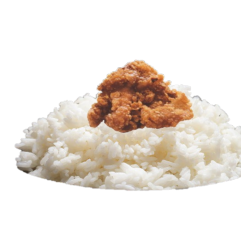

Set the fried chicken atop a bed of fragrant rice.
Lay the fried chicken portions on the rice.
Position the fried chicken onto the rice.
Arrange the fried chicken over the rice.
Place a bed of rice on a plate or in a bowl, and then arrange the fried chicken over it.
Put the fried chicken over the rice.
Craft a satisfying dish by placing a serving of rice on a plate or in a bowl and then adding the crispy fried chicken on top as a savory finishing touch.
To assemble the dish, start with a serving of rice and then add the fried chicken on top of it.
Place fried chicken on rice.


In [7]:
# Carregar a primeira imagem
image_file = f'{train_images_path}/1.png' 
image = Image.open(image_file)

# Carregar o primeiro texto
text_file = f'{train_labels_path}/1.txt'
with open(text_file, 'r') as file:
    text = file.read()

# Plotar a imagem e o texto
plt.figure(figsize=(3, 3))

# Mostrar a imagem
plt.imshow(image)
plt.axis('off')

plt.show()
print(text)

### 1. Dataset

In [16]:
class Bento800Dataset(Dataset):
    def __init__(self, images_dir, texts_dir, transform=None, vocab=None, max_length=50):
        self.images_dir = images_dir
        self.texts_dir = texts_dir
        self.transform = transform
        self.max_length = max_length

        if vocab is None:
            raise ValueError("Vocabulário (vocab) não pode ser None. Certifique-se de passar um dicionário de vocabulário.")

        self.vocab = vocab
        self.image_filenames = [f for f in os.listdir(images_dir) if f.endswith('.png')]

        print(f"Número de imagens encontradas: {len(self.image_filenames)}")

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        # Carrega a imagem
        img_name = self.image_filenames[idx]
        img_path = os.path.join(self.images_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        # Carrega o texto correspondente
        text_name = os.path.splitext(img_name)[0] + '.txt'
        text_path = os.path.join(self.texts_dir, text_name)

        with open(text_path, 'r') as file:
            text = file.read().strip()

        # Convertendo o texto para tokens (índices)
        tokens = self.text_to_indices(text)

        # Preenchendo os tokens até o comprimento máximo
        if len(tokens) > self.max_length:
            tokens = tokens[:self.max_length]
        else:
            tokens = tokens + [self.vocab['<PAD>']] * (self.max_length - len(tokens))

        tokens = torch.tensor(tokens, dtype=torch.long)

        return image, tokens

    def text_to_indices(self, text):
        # Supondo que vocabulário seja um dicionário {'palavra': índice}
        return [self.vocab.get(word, self.vocab['<UNK>']) for word in text.split()]

### 1.2 Funções auxiliares

In [17]:

def build_vocab(texts_dir, min_freq=1):
    """
    Constrói um vocabulário a partir dos textos em texts_dir.

    Args:
        texts_dir (str): Caminho para o diretório com os textos.
        min_freq (int): Frequência mínima para incluir uma palavra no vocabulário.

    Returns:
        vocab (dict): Dicionário que mapeia palavras para índices.
    """
    counter = Counter()

    # Iterar sobre todos os arquivos de texto
    for text_file in os.listdir(texts_dir):
        text_path = os.path.join(texts_dir, text_file)

        with open(text_path, 'r') as file:
            text = file.read().strip()
            words = text.split()
            counter.update(words)

    # Construir vocabulário com palavras que têm frequência maior ou igual a min_freq
    vocab = {'<PAD>': 0, '<UNK>': 1, '<start>': 2, '<end>': 3}
    idx = 4

    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = idx
            idx += 1

    return vocab

In [18]:
# Construindo o vocabulário
vocab = build_vocab(train_labels_path, min_freq=1)
vocab_size = len(vocab)
print(f"Vocab size: {vocab_size}")
print(f"Sample vocab: {list(vocab.items())[:10]}")

Vocab size: 254
Sample vocab: [('<PAD>', 0), ('<UNK>', 1), ('<start>', 2), ('<end>', 3), ('Set', 4), ('the', 5), ('fried', 6), ('chicken', 7), ('atop', 8), ('a', 9)]


In [19]:
# Definindo transformações para as imagens (redimensionamento, normalização, etc.)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [20]:
def custom_collate_fn(batch):
    images, captions = zip(*batch)

    # Empilhando as imagens. Todas devem ter o mesmo tamanho
    images = torch.stack(images, 0)

    # Preenchendo as sequências para o mesmo comprimento
    caption_lengths = [len(caption) for caption in captions]
    max_length = max(caption_lengths)
    padded_captions = torch.zeros(len(captions), max_length).long()

    for i, caption in enumerate(captions):
        end = caption_lengths[i]
        padded_captions[i, :end] = caption[:end]

    return images, padded_captions

### 1.3 Criando os datasets

In [23]:
# Criando os datasets
train_dataset = Bento800Dataset(
    images_dir=train_images_path,
    texts_dir=train_labels_path,
    transform=transform,
    vocab=vocab
)

test_dataset = Bento800Dataset(
    images_dir=test_images_path,
    texts_dir=test_labels_path,
    transform=transform,
    vocab=vocab
)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, collate_fn=custom_collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0, collate_fn=custom_collate_fn)
train_loader_iter = iter(train_loader)
images, texts = next(train_loader_iter)

Número de imagens encontradas: 766
Número de imagens encontradas: 34


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.129035].


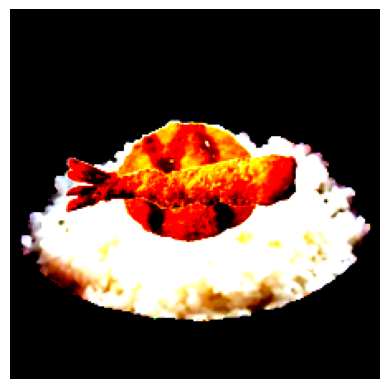

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5877128].


tensor([ 87,   5,  22,  50,   9, 225,  27,   6, 232,  36,   5, 226,  16,   5,
        228,  21,   5, 225,  27,   6, 226,  16,   5,  10,  11, 105,  50,   5,
        226, 227,  16,  41,  11,   5, 228,  17,   5, 225,  27,   6, 226,  20,
          5, 105,  50,   5, 226, 229, 244,   5])


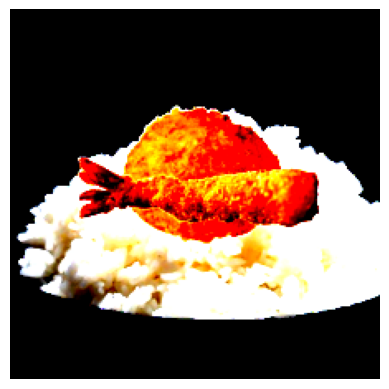

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


tensor([ 19,   5, 225,  27,   6, 226,  20,   5, 105,  50,   5, 226, 229,  16,
          5, 228,  21,   5, 225,  27,   6, 226,  16,   5, 105,  50,   5, 226,
        229,  16,  41,  11,   5, 228,  64,   5,  22,  50,   9, 225,  27,   6,
        232, 230,   5, 226, 166, 231,  20,   5])


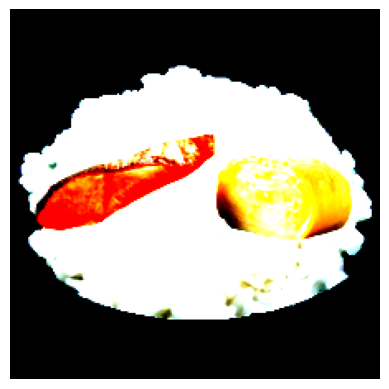

tensor([125, 138, 139,  27, 141,  16,  41,  11,   5,  13,  17,   5, 138, 139,
         27, 141,  18,   5,  13,  64,   5,  22,  50,   9,  69,  11, 138, 139,
         27, 140, 104, 138, 139,  27, 141,  16,   9,  10,  11,  13,  46,  80,
          9,  66,  59,  85,   9,  95,  11, 131])


In [24]:
# Função para mostrar a imagem e o texto correspondente
def show_sample(image, text):
    plt.imshow(image.permute(1, 2, 0))  # Converte a imagem de [C, H, W] para [H, W, C]
    plt.axis('off')
    plt.show()
    print(text)

# Obtendo uma amostra do dataset de treino
train_loader_iter = iter(train_loader)
images, texts = next(train_loader_iter)

# Exibindo as primeiras 3 amostras
for i in range(3):
    show_sample(images[i], texts[i])

# 2. Modelo

### 2.1 Attention Model

A camada de Atenção calcula o vetor de contexto, pesando as características extraídas da imagem de acordo com o estado oculto do LSTM. Ela é composta por uma camada linear para combinar as características da imagem e o estado oculto. Uma segunda camada linear que gera os pesos de atenção, seguidos por uma operação de Softmax para normalização. Tem como saída um vetor de contexto ponderado, utilizado pelo decodificador.

In [25]:
class Attention(nn.Module):
    def __init__(self, feature_dim, hidden_dim, attention_dim):
        super(Attention, self).__init__()
        self.attention_fc = nn.Linear(feature_dim + hidden_dim, attention_dim)
        self.attention_out = nn.Linear(attention_dim, 1)

    def forward(self, features, hidden_state):

        hidden_state = hidden_state.unsqueeze(1).repeat(1, features.size(1), 1)
        attention_input = torch.cat([features, hidden_state], dim=2)
        attention_score = torch.tanh(self.attention_fc(attention_input))
        attention_weights = torch.softmax(self.attention_out(attention_score), dim=1)
        context_vector = torch.sum(attention_weights * features, dim=1)

        return context_vector, attention_weights

### 2.2 Encoder

O Encoder CNN extrai características das imagens através de três camadas convolucionais (Conv2d) com 32, 64 e 128 filtros, respectivamente, cada uma seguida por uma camada de ativação ReLU e uma camada de MaxPooling (reduzindo a dimensionalidade pela metade).As saídas são achatadas e passadas por duas camadas totalmente conectadas (512 e 256 neurônios), com Dropout de 50% aplicado para regularização. Gerando por fim um vetor de características de dimensão 256.

In [26]:
class CNNEncoder(nn.Module):
    def __init__(self):
        super(CNNEncoder, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, 256)
        self.dropout = nn.Dropout(0.5)  # Dropout de 50%

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)  # Flatten na saída
        x = self.dropout(F.relu(self.fc1(x)))  # Adicionar Dropout
        features = self.dropout(F.relu(self.fc2(x)))  # Adicionar Dropout
        return features

### 2.3 Decoder

O Decoder RNN com Atenção gera a sequência textual baseada nas características da imagem e no vetor de contexto gerado pela atenção. É composta por um embedding que mapeia as palavras das legendas em vetores densos, seguida de uma LSTM que recebe como entrada os vetores de embedding concatenados com o vetor de contexto da atenção. Por fim, uma camada totalmente conectada (Linear) que mapeia a saída do LSTM para o espaço do vocabulário, tendo como saída uma sequência de palavras que formam a legenda da imagem.

In [27]:
class RNNDecoderWithAttention(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers, feature_dim, attention_dim):
        super(RNNDecoderWithAttention, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.attention = Attention(feature_dim, hidden_dim, attention_dim)
        self.lstm = nn.LSTM(input_size=embedding_dim + feature_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True, dropout=0.5)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, features, captions):
        embedded = self.embedding(captions)
        hidden_state = torch.zeros(features.size(0), self.lstm.hidden_size).to(features.device)
        context_vector, _ = self.attention(features, hidden_state)

        lstm_input = torch.cat((context_vector.unsqueeze(1).repeat(1, embedded.size(1), 1), embedded), dim=2)
        lstm_out, _ = self.lstm(lstm_input)
        outputs = self.fc(lstm_out)
        return outputs

### 2.4 Attention-based LSTM

In [28]:
class ImageToTextModelWithAttention(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers, feature_dim, attention_dim):
        super(ImageToTextModelWithAttention, self).__init__()
        self.encoder = CNNEncoder()
        self.decoder = RNNDecoderWithAttention(vocab_size, embedding_dim, hidden_dim, num_layers, feature_dim, attention_dim)

    def forward(self, images, captions):
        features = self.encoder(images).unsqueeze(1)
        outputs = self.decoder(features, captions)
        return outputs

In [36]:
# Assumindo o dispositivo está definido como 'cpu' ou 'cuda'
model = ImageToTextModelWithAttention(vocab_size=5000, embedding_dim=256, hidden_dim=512, num_layers=2, feature_dim=256, attention_dim=256).to(device)

# Sumário para o Encoder CNN
print("Sumário CNN Encoder:")
summary(model.encoder, input_size=(3, 224, 224))

def get_decoder_summary(model, features, captions):
    model.eval()  # Definir o modelo em modo de avaliação
    with torch.no_grad():
        output = model(features, captions)
    return output

# Exemplo de entradas
features_example = torch.randn(2, 49, 256).to(device)  # batch_size=2, num_pixels=49, feature_dim=256
captions_example = torch.randint(0, 5000, (2, 50)).to(device)  # batch_size=2, seq_len=50

# Obter o resumo do decodificador
outputs = get_decoder_summary(model.decoder, features_example, captions_example)

# Imprimir a arquitetura do modelo
print("RNNDecoderWithAttention Architecture:")
print(model.decoder)
print("\nExample Output Shape:", outputs.shape)

Sumário CNN Encoder:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             896
         MaxPool2d-2         [-1, 32, 112, 112]               0
            Conv2d-3         [-1, 64, 112, 112]          18,496
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5          [-1, 128, 56, 56]          73,856
         MaxPool2d-6          [-1, 128, 28, 28]               0
            Linear-7                  [-1, 512]      51,380,736
           Dropout-8                  [-1, 512]               0
            Linear-9                  [-1, 256]         131,328
          Dropout-10                  [-1, 256]               0
Total params: 51,605,312
Trainable params: 51,605,312
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.57
Forward/backward pass size (MB): 26.81
Params

# 4. Treinamento

O algoritmo de otimização utilizado para o treinamento da rede foi o Adam, que fornece uma estabilidade no aprendizado, ou seja, no ajuste dos pesos. Isso ocorre pois, em uma RNN com atenção, o fluxo de gradientes pode variar muito. Além disso, como o Adam ajusta a taxa de aprendizado de cada parâmetro de forma independente, ele pode ajudar a evitar problemas de treinamento como a saturação de um peso para uma feature específica. 
Enquanto isso, valor de decaimento dos pesos é basicamente uma regularização L2, que ajuda a evitar o overfitting. Também foi utilizada CrossEntropyLoss como função de perda.  Por fim, foi também utilizado o clipping de gradientes, utilizado para evitar que os gradientes se tornem muito grandes durante o treinamento

In [37]:
def test_model(model, test_loader, criterion):
    model.eval()
    total_test_loss = 0.0
    all_test_predictions = []
    all_test_references = []

    with torch.no_grad():
        for images, captions in test_loader:
            images = images.to(device)
            captions = captions.to(device)

            outputs = model(images, captions)

            outputs = outputs.view(-1, outputs.size(2))
            captions = captions.view(-1)

            loss = criterion(outputs, captions)
            total_test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            all_test_predictions.extend(predicted.cpu().numpy())
            all_test_references.extend(captions.cpu().numpy())

    avg_test_loss = total_test_loss / len(test_loader)
    test_accuracy = accuracy_score(all_test_references, all_test_predictions)
    test_precision = precision_score(all_test_references, all_test_predictions, average='weighted', zero_division=0)

    print(f'Test Loss: {avg_test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, Test Precision: {test_precision:.4f}')

    return avg_test_loss, test_accuracy, test_precision

In [38]:
def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=10, test_interval=5):
    train_loss_history = []
    train_accuracy_history = []
    train_precision_history = []

    test_loss_history = []
    test_accuracy_history = []
    test_precision_history = []

    for epoch in range(num_epochs):
        model.train()
        total_train_loss = 0.0
        all_train_predictions = []
        all_train_references = []

        for images, captions in train_loader:
            images = images.to(device)
            captions = captions.to(device)

            optimizer.zero_grad()
            outputs = model(images, captions)

            outputs = outputs.view(-1, outputs.size(2))
            captions = captions.view(-1)

            loss = criterion(outputs, captions)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)

            optimizer.step()

            total_train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            all_train_predictions.extend(predicted.cpu().numpy())
            all_train_references.extend(captions.cpu().numpy())

        avg_train_loss = total_train_loss / len(train_loader)
        train_loss_history.append(avg_train_loss)

        train_accuracy = accuracy_score(all_train_references, all_train_predictions)
        train_precision = precision_score(all_train_references, all_train_predictions, average='weighted', zero_division=0)
        train_accuracy_history.append(train_accuracy)
        train_precision_history.append(train_precision)

        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, Train Precision: {train_precision:.4f}')

        # Realiza o teste a cada 'test_interval' épocas
        if (epoch + 1) % test_interval == 0:
            test_loss, test_accuracy, test_precision = test_model(model, test_loader, criterion)
            test_loss_history.append(test_loss)
            test_accuracy_history.append(test_accuracy)
            test_precision_history.append(test_precision)

    return (train_loss_history, train_accuracy_history, train_precision_history,
            test_loss_history, test_accuracy_history, test_precision_history)

In [39]:
# Hiperparâmetros
embedding_dim = 256
hidden_dim = 512
num_layers = 1
attention_dim = 256  # Tamanho do vetor de atenção
feature_dim = 256  # Tamanho da saída do CNNEncoder
learning_rate = 0.0005
weight_decay = 1e-3
num_epochs = 10

# Inicializar o modelo
model = ImageToTextModelWithAttention(vocab_size, embedding_dim, hidden_dim, num_layers, feature_dim, attention_dim).to(device)

# Perda e otimizador
criterion = nn.CrossEntropyLoss(ignore_index=vocab['<PAD>'])
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

c:\Users\jllgo\anaconda3\envs\pytorch_env\lib\site-packages\torch\nn\modules\rnn.py:83: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


In [40]:
test_interval = 3

# Treinando e testando o modelo
(train_loss_history, train_accuracy_history, train_precision_history,
test_loss_history, test_accuracy_history, test_precision_history) = train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=num_epochs, test_interval=test_interval)

Epoch [1/10], Train Loss: 3.4316, Train Accuracy: 0.3901, Train Precision: 0.5036
Epoch [2/10], Train Loss: 1.0827, Train Accuracy: 0.8441, Train Precision: 0.8326
Epoch [3/10], Train Loss: 0.3303, Train Accuracy: 0.9737, Train Precision: 0.9625
Test Loss: 0.2929, Test Accuracy: 0.9824, Test Precision: 0.9693
Epoch [4/10], Train Loss: 0.1250, Train Accuracy: 0.9895, Train Precision: 0.9828
Epoch [5/10], Train Loss: 0.0726, Train Accuracy: 0.9937, Train Precision: 0.9900
Epoch [6/10], Train Loss: 0.0502, Train Accuracy: 0.9969, Train Precision: 0.9952
Test Loss: 0.0630, Test Accuracy: 0.9971, Test Precision: 0.9956
Epoch [7/10], Train Loss: 0.0372, Train Accuracy: 0.9987, Train Precision: 0.9981
Epoch [8/10], Train Loss: 0.0304, Train Accuracy: 0.9995, Train Precision: 0.9991
Epoch [9/10], Train Loss: 0.0262, Train Accuracy: 0.9997, Train Precision: 0.9994
Test Loss: 0.0329, Test Accuracy: 0.9994, Test Precision: 0.9988
Epoch [10/10], Train Loss: 0.0250, Train Accuracy: 0.9997, Train Pr

### 4.2 Métricas

In [41]:
# plotar as metricas
def plot_metrics(num_epochs, train_metrics, test_metrics, metric_name, test_interval):
    epochs = range(1, num_epochs + 1)
    test_epochs = range(test_interval, num_epochs + 1, test_interval)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_metrics, 'bo-', label=f'Train {metric_name}')
    plt.plot(range(test_interval, 11, test_interval), test_metrics, 'ro-', label=f'Test {metric_name}')
    plt.xlabel('Epochs')
    plt.ylabel(metric_name)
    plt.title(f'Train vs Test {metric_name} per Epoch')
    plt.legend()
    plt.grid(True)
    plt.show()

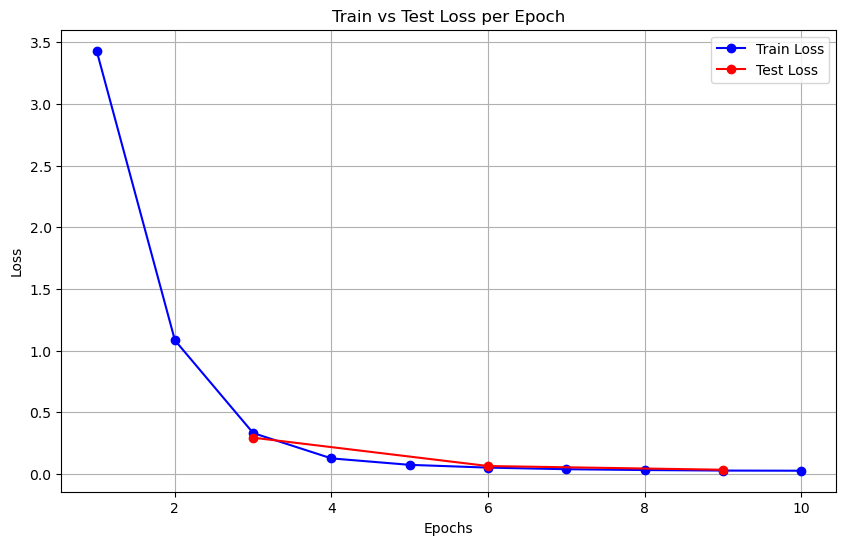

In [42]:
plot_metrics(num_epochs, train_loss_history, test_loss_history, 'Loss', test_interval)

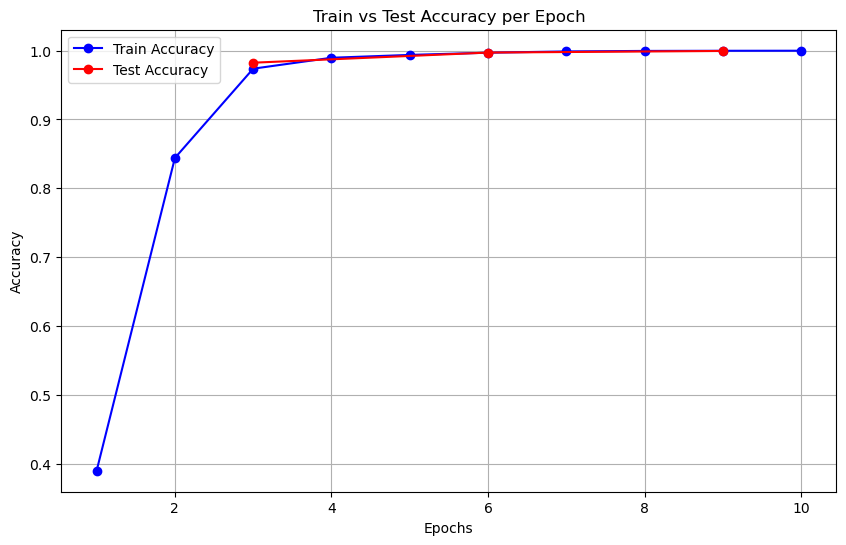

In [43]:
plot_metrics(num_epochs, train_accuracy_history, test_accuracy_history, 'Accuracy', test_interval)

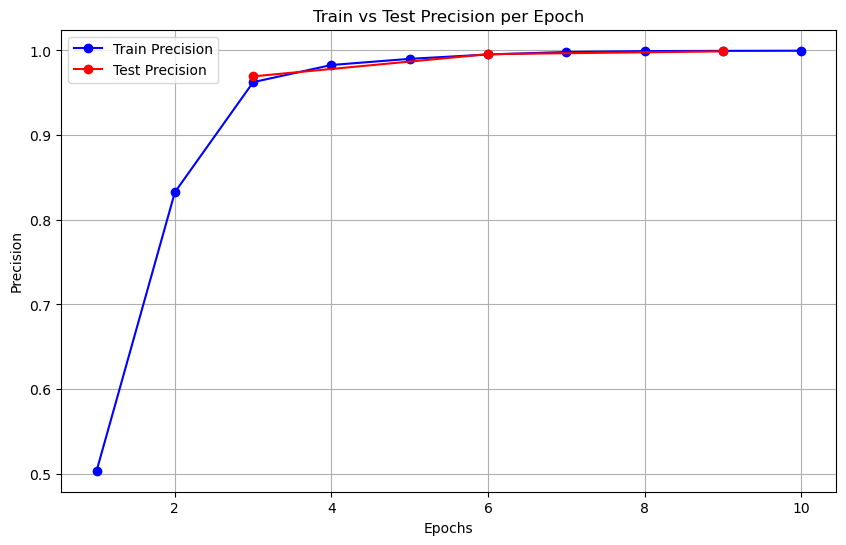

In [44]:
plot_metrics(num_epochs, train_precision_history, test_precision_history, 'Precision', test_interval)

# 5. Resultados

In [45]:
def plot_images_with_captions(images, captions):
    # Certifique-se de que as imagens estão no formato [C, H, W]
    images = images.permute(0, 2, 3, 1).cpu().numpy()

    for i in range(len(images)):
        plt.imshow(images[i])
        print(captions[i])
        plt.axis('off')
        plt.show()

### 5.1 Beam Search

Primeiro, geraram-se legendas para um conjunto de imagens usando a técnica de beam search, que ajuda a prever as melhores sequências de palavras com base nas probabilidades fornecidas pelo modelo. Em seguida, essas legendas foram exibidas junto com as imagens correspondentes para visualização e análise dos resultados.

In [46]:
def beam_search_decoder(predictions, beam_width=3):
    sequences = [[[], 0.0]]

    # Itera sobre cada previsão (correspondente a cada palavra na sequência)
    for row in predictions:
        all_candidates = list()
        for i in range(len(sequences)):
            seq, score = sequences[i]
            for j in range(len(row)):
                candidate = [seq + [j], score - torch.log(row[j])]
                all_candidates.append(candidate)
        ordered = sorted(all_candidates, key=lambda tup: tup[1])
        sequences = ordered[:beam_width]

    # Retorna a sequência com a maior pontuação
    return sequences[0][0]

In [47]:
def generate_caption_with_beam_search(model, image, vocab, beam_width=3, max_length=20, device='cpu'):
    model.eval()
    idx_to_word = {idx: word for word, idx in vocab.items()}
    with torch.no_grad():
        # Extração das características da imagem
        feature = model.encoder(image.unsqueeze(0).to(device)).unsqueeze(1)
        caption = [vocab['<start>']]

        for _ in range(max_length):
            caption_tensor = torch.tensor(caption).unsqueeze(0).to(device)
            outputs = model.decoder(feature, caption_tensor)
            outputs = torch.softmax(outputs, dim=-1)
            predicted_caption = beam_search_decoder(outputs[0].cpu(), beam_width=beam_width)

            next_word_idx = predicted_caption[-1]
            caption.append(next_word_idx)

            if next_word_idx == vocab['<end>']:
                break

    # Converte a sequência de índices para palavras
    caption_words = [idx_to_word[idx] for idx in caption if idx in idx_to_word]

    return ' '.join(caption_words[1:-1])  # Remove os tokens <start> e <end>

In [48]:
# Teste a nova função de geração de legendas
def evaluate_and_plot_results_with_beam_search(model, data_loader, vocab, device='cpu', num_samples=5, beam_width=3):
    model.eval()
    idx_to_word = {idx: word for word, idx in vocab.items()}

    data_iter = iter(data_loader)
    images, _ = next(data_iter)
    images = images[:num_samples].to(device)

    captions = []
    for i in range(num_samples):
        caption = generate_caption_with_beam_search(model, images[i], vocab, beam_width=beam_width, device=device)
        captions.append(caption)

    print(captions)
    plot_images_with_captions(images.cpu(), captions)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6051416].


['with with with with with with with with with with with with with with with with with with with', 'with with with with with with with with with with with with with with with with with with with', 'with with with with with with with with with with with with with with with with with with with']
with with with with with with with with with with with with with with with with with with with


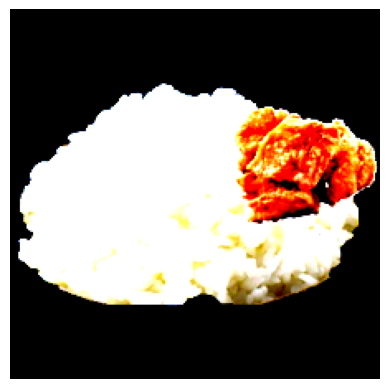

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].


with with with with with with with with with with with with with with with with with with with


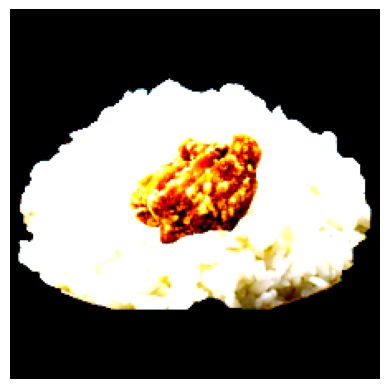

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5877128].


with with with with with with with with with with with with with with with with with with with


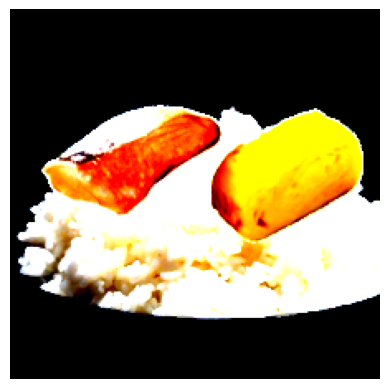

In [49]:
evaluate_and_plot_results_with_beam_search(model, test_loader, vocab, device=device, num_samples=3, beam_width=3)